## PSILO

In [2]:
#Libraries 
import os
import time
import math
import numpy as np
import pandas as pd
import scipy
import scipy.signal as spsg
from scipy import stats
from scipy.io import loadmat
from scipy.spatial.distance import squareform, pdist
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.cluster import KMeans
from scipy.spatial.distance import cityblock
from data.labels_brain import reorder_matrix
from tqdm import tqdm
from scipy.stats import pearsonr
from data.diagram_plots import Region_Heatmap,chord_diagram


#random.seed(42)

### Reading Data

In [3]:
# Read the data
data_path= "C:/Users/diego/Desktop/phase_coherance_consciousness/data"

#Some of the data is corrupted, we chose manually the patiens we want to read.
num_patients=[0,1,2,3,4,6,7,8,9,10,12,13,14]
num=len(num_patients)

data_PSILO = os.path.join(data_path, "PSILO_TS_FC.mat")
data_PSILO = loadmat(data_PSILO)
data_PSILO = data_PSILO["DataCorrel"].flatten()

#Some of the data is corrupted, we chose manually the patiens we want to read.
#num_patients=range(data_PSILO["TS_Psilo"].shape[0])
num_patients=[0,1,2,3,4,6,7,8,9,10,12,13,14]
num=len(num_patients)

PSILOACAT = np.hstack([data_PSILO["TS_Psilo"][i] for i in num_patients])
PSILOPCAT = np.hstack([data_PSILO["TS_PCB"][i] for i in num_patients])

PSILO_Signals = np.hstack((PSILOACAT, PSILOPCAT))
print(f"PSILO concatenated signals: {PSILO_Signals.shape} from {data_PSILO.shape[0]} patients.")

PSILO concatenated signals: (90, 2487) from 15 patients.


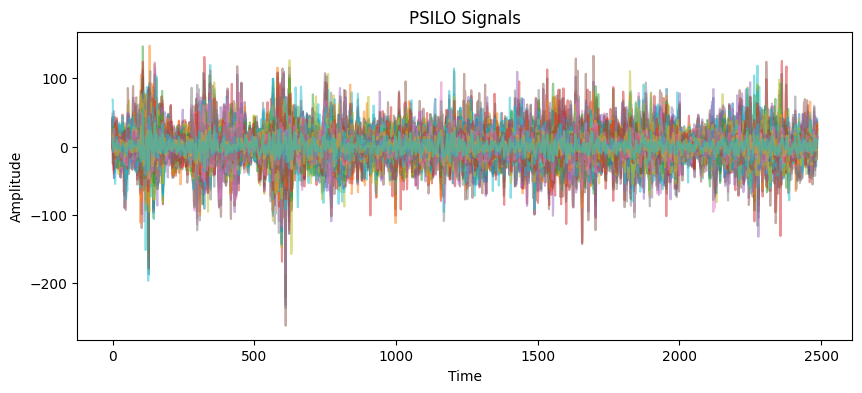

In [4]:
# Initial visualization of the Bold Signals (Time Series)
plt.figure(figsize=(10, 4))
plt.plot(PSILO_Signals.T, alpha=0.5)
plt.title("PSILO Signals")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

### Extract Size and Features

In [5]:
#Number of Regions and Total Time
ROI,time_length = PSILO_Signals.shape

# Loop over each region to extract the lenght of each signal.
Time_per_subj = np.zeros(ROI, dtype=int)
for i in range(ROI):
    Time_per_subj[i] = len(PSILO_Signals[i])


print(f" Number of Regions (ROI): {ROI} \n Total Time: {time_length}")

 Number of Regions (ROI): 90 
 Total Time: 2487


### Import the Connectoma 

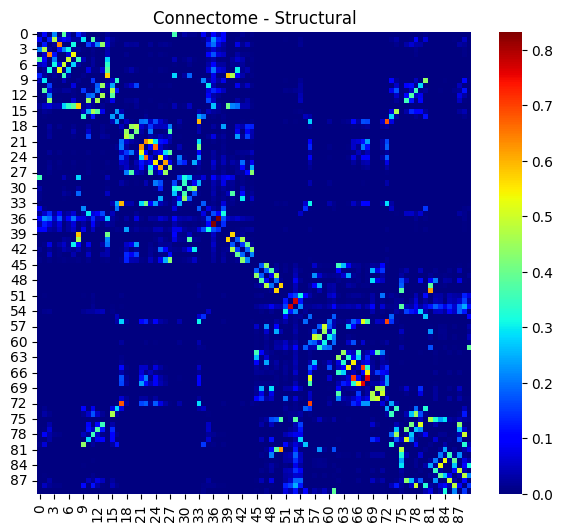

In [6]:
# Import the atlas
data_connectome = os.path.join(data_path, "./structural.mat")
CC = loadmat(data_connectome)['A']

# Plot it
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(CC, cmap='jet',cbar=True, ax=ax)
ax.set_title(f"Connectome - Structural")
plt.show()

In [7]:
np.info(CC)

class:  ndarray
shape:  (90, 90)
strides:  (8, 720)
itemsize:  8
aligned:  True
contiguous:  False
fortran:  True
data pointer: 0x1e6b99500c0
byteorder:  little
byteswap:  False
type: float64


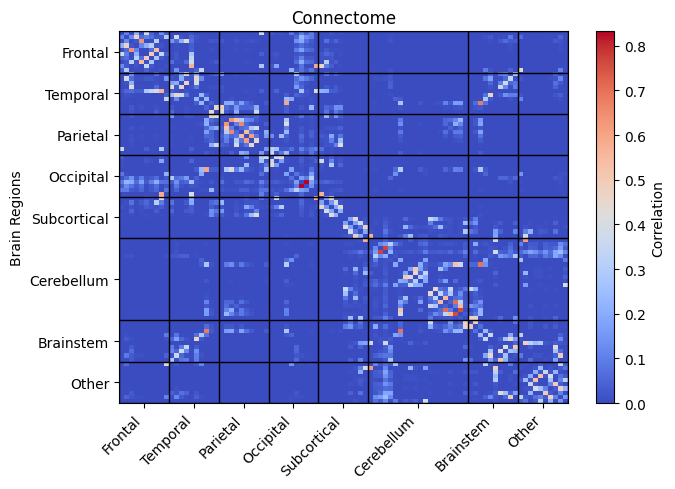

In [8]:
#Example of Usage (Region-Heatmap)
fig = Region_Heatmap(CC, 
                     region_boundaries=[10,20,30,40,50,70,80,90],
                     region_names = ["Frontal", "Temporal", "Parietal", "Occipital", "Subcortical", "Cerebellum", "Brainstem", "Other"],
                     name="Connectome",
                     scaling=True)
plt.show()

### Preprocess Functions 

In [9]:
# Function to apply a Butterworth bandpass filter to a time series.
# It is particularly useful for removing noise and smoothing the signal in the specified frequency range.
def butterworth_filtering(ts):
    """
    Apply a Butterworth bandpass filter to the input time series `ts`.

    Parameters:
    ts : array-like
        The input time series (1D or 2D array).
        
    Returns:
    filtered_ts : array-like
        The filtered time series, same shape as input.
        
    Notes:
    - The filter settings are dependent on the experimental setup (TR = 2.4 seconds).
    - A 3rd-order Butterworth bandpass filter is applied with cutoff frequencies of 0.01 and 0.2 times the Nyquist frequency.
    - The Nyquist frequency is determined by the repetition time (TR = 2.4s).
    """
    # Parameters
    n_order = 3  # Filter order
    TR = 2.4  # Repetition time (in seconds, relevant for fMRI experiments)
    Nyquist_freq = 0.5 / TR  # Nyquist frequency (half the sampling rate)
    low_f = 0.01 / Nyquist_freq  # Low cutoff frequency (fraction of Nyquist)
    high_f = 0.2 / Nyquist_freq  # High cutoff frequency (fraction of Nyquist)
    
    # Design the Butterworth bandpass filter
    b, a = spsg.iirfilter(n_order, (low_f, high_f), btype='bandpass', ftype='butter', output='ba')
    
    # Apply the filter to the time series using zero-phase filtering
    filtered_ts = spsg.filtfilt(b, a, ts, axis=-1)
    
    return filtered_ts

In [10]:
def adif(a, b):
    """
    Calculate the angular difference between two angles `a` and `b` in radians.

    Parameters:
    a, b : float
        The input angles in radians.
        
    Returns:
    float
        The angular difference between the two angles, always in the range [0, π]. The smallest angel diffence.
    """
    if abs(a - b) > math.pi:
        return 2 * math.pi - abs(a - b)
    else:
        return abs(a - b)


### Phase difference between each pair of regions

In [11]:
timeseriedata = np.empty((ROI, time_length))
Amplitude = np.empty((ROI, time_length))
Phases = np.empty((ROI, time_length))

# For each Region we preprocess the signal to exctract instantaneous phase
for i in range(ROI):

    #Extract the signal
    ts = PSILO_Signals[i,:]

    # Normalize the signal using Z-score
    ts_z = stats.zscore(ts)

    # Subtract the mean
    ts_z = ts_z-np.mean(ts_z,axis=0)

    # Apply the Butterworth filter 
    #ts_filtered = butterworth_filtering(ts_z)
    ts_filtered = ts_z
    
    timeseriedata[i, :] = ts_filtered

    # Perform the Hilbert transform
    hilbert_tf = spsg.hilbert(ts_z, axis=-1)
    Amplitude[i, :] = np.abs(hilbert_tf)

    # Instantaneous phase
    Phases[i, :] = np.angle(hilbert_tf)

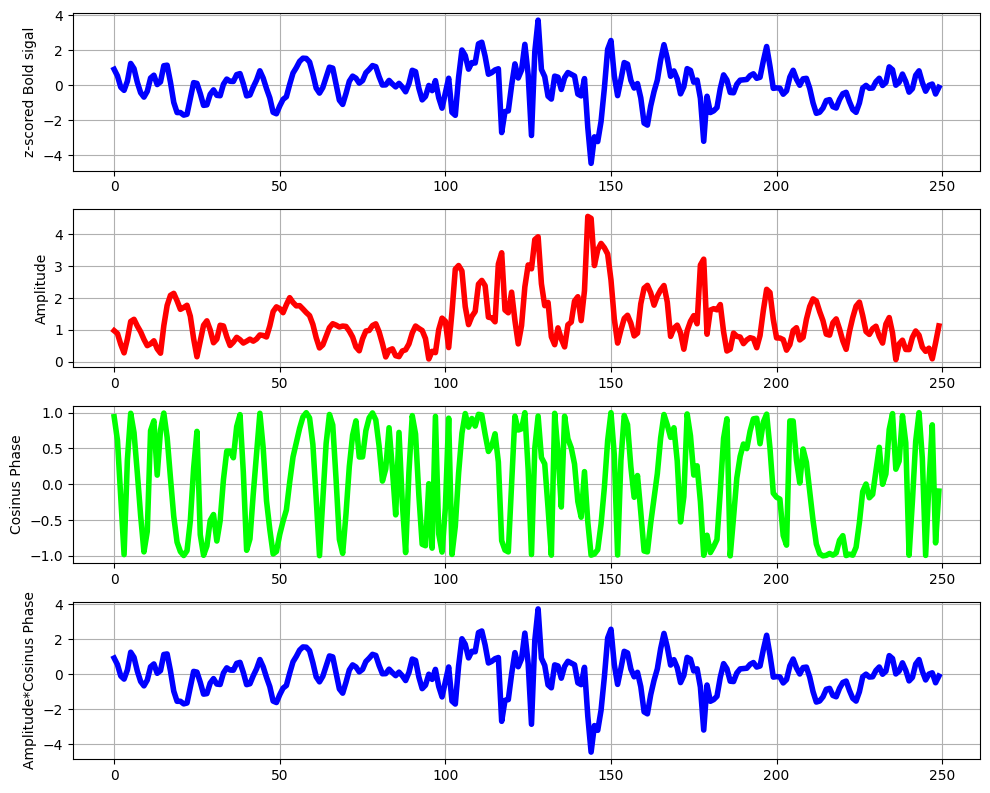

In [12]:
def createfigure(Y1, Y2, Y3, Y4):
    """
    Creates a figure with 4 vertical subplots to visualize:
    - Y1: Z-scored signal (e.g., bold)
    - Y2: Amplitude
    - Y3: Cosine of the phase
    - Y4: Amplitude * cosine of the phase
    """

    fig, axs = plt.subplots(4, 1, figsize=(10, 8))
    
    axs[0].plot(Y1, linewidth=4, color=[0, 0, 1])
    axs[0].set_ylabel('z-scored Bold sigal')
    axs[0].grid(True) 
    
    axs[1].plot(Y2, linewidth=4, color=[1, 0, 0])
    axs[1].set_ylabel('Amplitude')
    axs[1].grid(True)
    
    
    axs[2].plot(Y3, linewidth=4, color=[0, 1, 0])
    axs[2].set_ylabel('Cosinus Phase')
    axs[2].grid(True)
    
    axs[3].plot(Y4, linewidth=4, color=[0, 0, 1])
    axs[3].set_ylabel('Amplitude*Cosinus Phase')
    axs[3].grid(True)
    
    plt.tight_layout()
    plt.show()

#We replicate a signal
Y1 = timeseriedata[0, :250]
Y2 = Amplitude[0, :250]
Y3 = np.cos(Phases[0, :250])
Y4 = Amplitude[0, :250] * np.cos(Phases[0, :250])
createfigure(Y1, Y2, Y3, Y4)

### Vectorized Computation for each time instant 

In [13]:
# Number of pairs (only the lower part of the matrix): ROI*(ROI-1)/2
row_idx, col_idx = np.tril_indices(ROI, k=-1)
sorted_indices = np.lexsort((row_idx, col_idx))
lower_indices_corrected = (row_idx[sorted_indices], col_idx[sorted_indices])


num_pairs = len(lower_indices_corrected[0])
pattern = np.empty((num_pairs, time_length))


# Vectorized computation for each time instant
for t in range(time_length):
    patt = np.empty((ROI, ROI))
    for i in range(ROI):
        for j in range(i):
            patt[i,j] = np.cos(adif(Phases[i,t],Phases[j,t]))
    pattern[:, t] = patt[lower_indices_corrected]
    

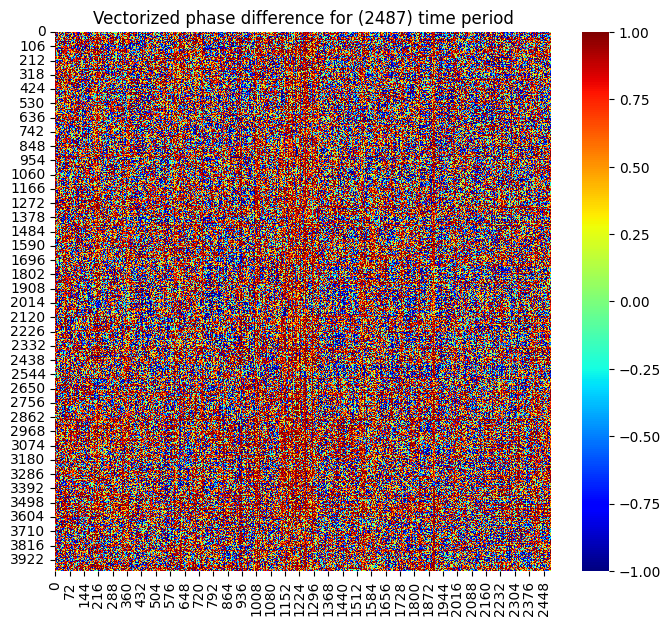

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pattern, cmap='jet', vmin=-1, vmax=1, cbar=True, ax=ax)
ax.set_title(f"Vectorized phase difference for ({time_length}) time period")
plt.show()

### Remove Empty Images

In [15]:
all_pattern2D = pattern.T


# Empty Images
print("Size before removing empty images:", all_pattern2D.shape)
good_pattern = np.sum(np.abs(all_pattern2D), axis=1) > 0
all_pattern2D = all_pattern2D[good_pattern, :]  
print("Size after removing empty images:", all_pattern2D.shape)

# Outliers
# D = squareform(pdist(all_pattern2D, metric='cityblock'))  
# D = zscore(np.mean(D, axis=1))  
# good_pattern = D < 3 
# all_pattern2D = all_pattern2D[good_pattern, :]  
print("Size after removing outliers:", all_pattern2D.shape)


Size before removing empty images: (2487, 4005)
Size after removing empty images: (2487, 4005)
Size after removing outliers: (2487, 4005)


### Convergence Analysis

Running clustering experiments...


Experiments: 100%|██████████| 5/5 [00:41<00:00,  8.34s/it]


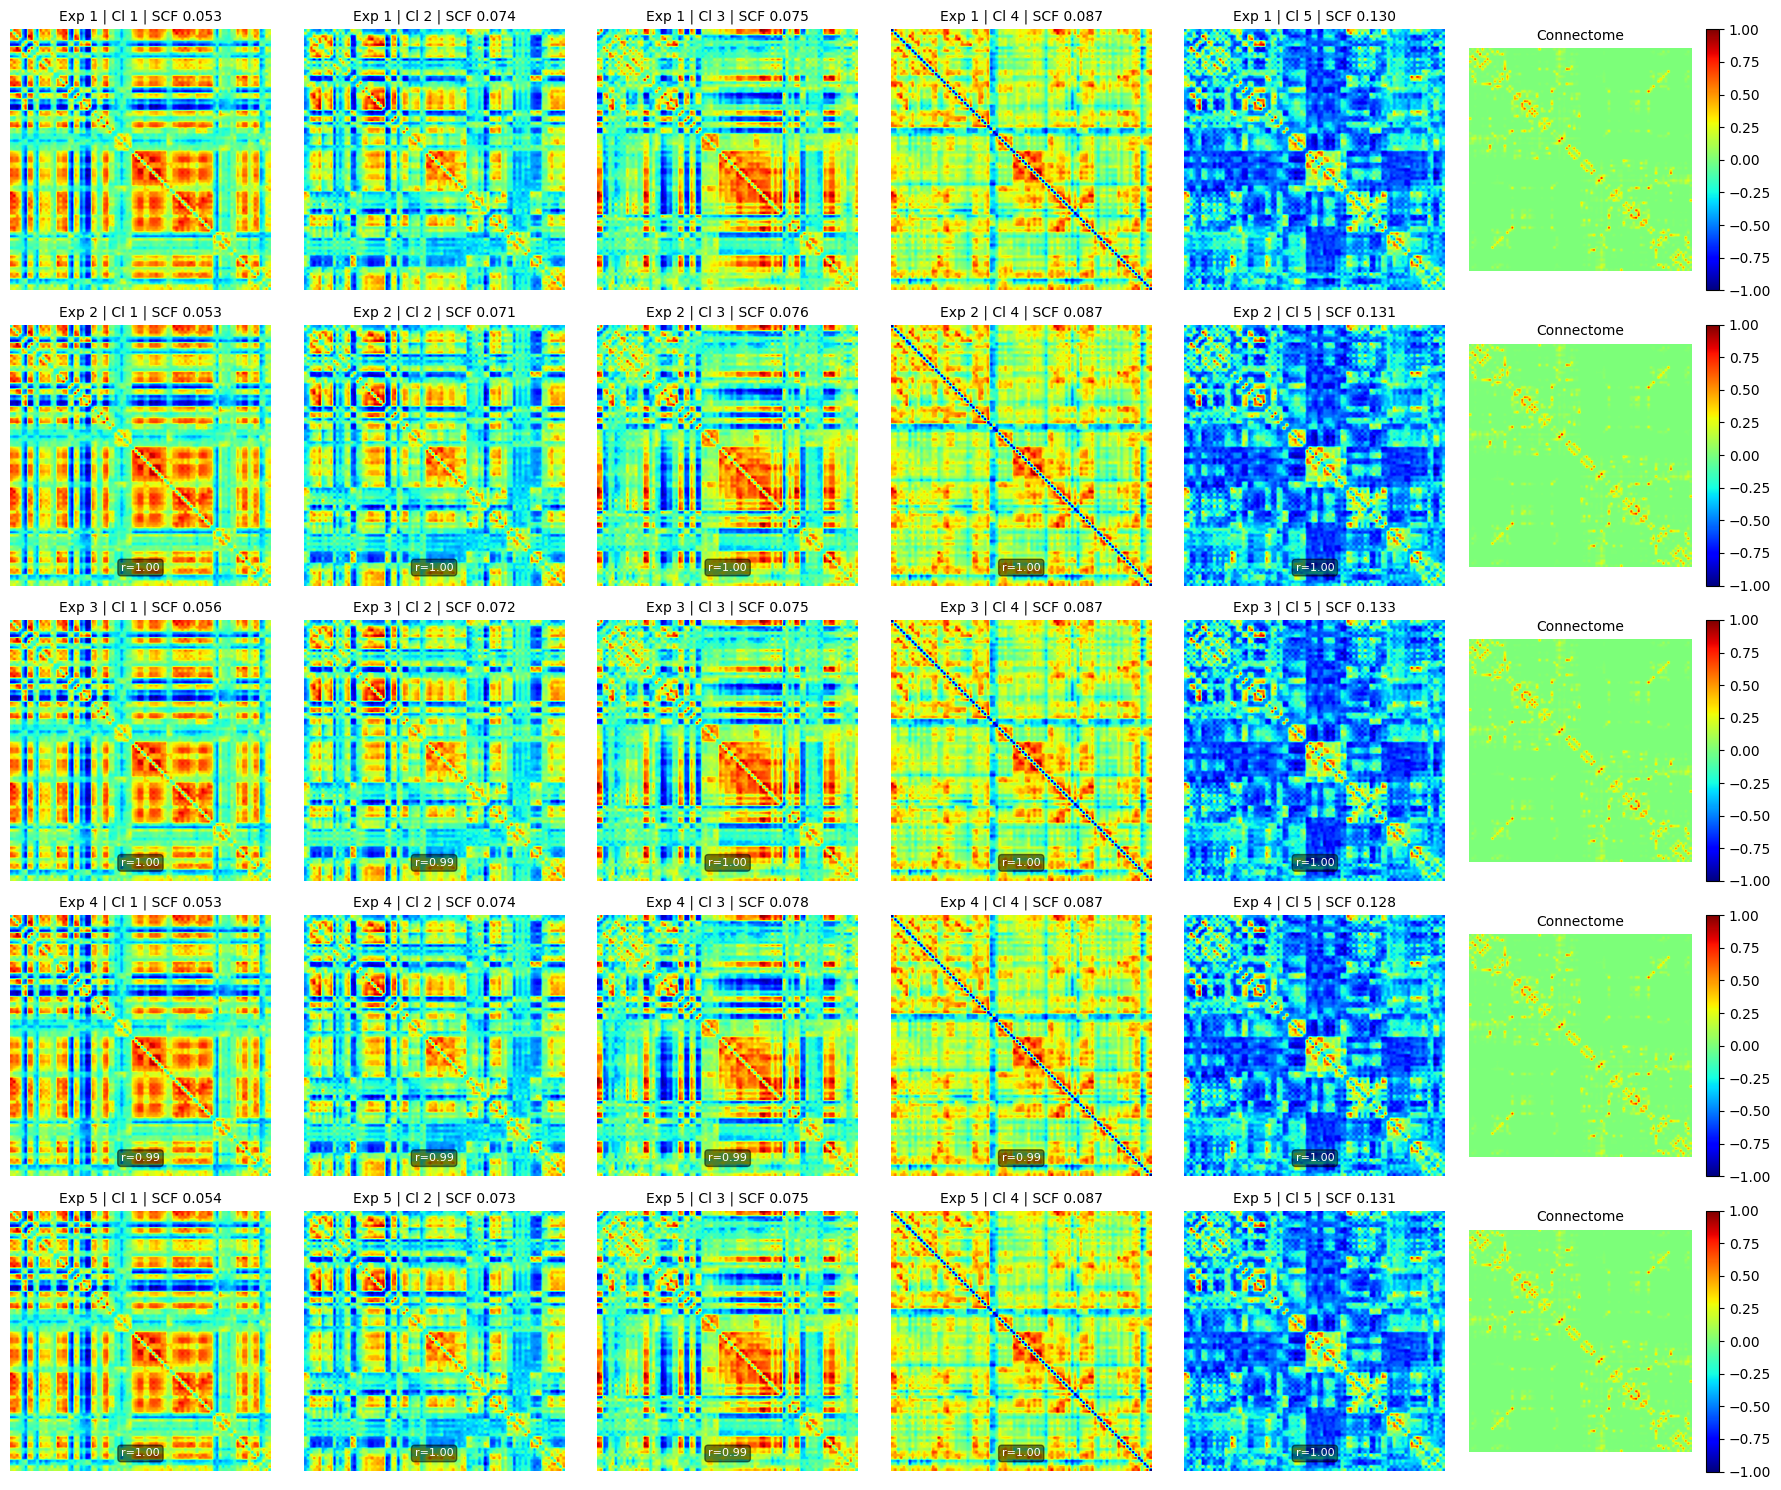

In [16]:
# ------------------------------
# Parameters for Experiments
# ------------------------------
n_clusters = 5        
max_iter = 40  
n_init = 20     
n_experiments = 5

# ------------------------------
# Run the Experiments
# ------------------------------
experiments_results = []
print("Running clustering experiments...")
for exp in tqdm(range(n_experiments), desc="Experiments"):
    kmeans = KMeans(n_clusters=n_clusters, max_iter=max_iter, n_init=n_init, random_state=None)
    kmeans.fit(all_pattern2D)
    experiments_results.append({
        'ctrs_Pha': kmeans.cluster_centers_, 
        'cidx_Pha': kmeans.labels_
    })

# ------------------------------
# Create a n_experiments x (n_clusters + connectome) Grid Plot
# ------------------------------
#fig, axs = plt.subplots(n_experiments, n_clusters, figsize=(n_clusters*3, n_experiments*3))
fig, axs = plt.subplots(n_experiments, n_clusters + 1, figsize=((n_clusters+1)*3, n_experiments*3))

# Flatten the connectome matrix
VC = CC.flatten().astype(np.float64)
sorted_indices = []

for exp in range(n_experiments):
    result = experiments_results[exp]

    CCA = np.zeros(n_clusters)
    for i in range(n_clusters):
        centroid_vector = result['ctrs_Pha'][i, :]
        QQ = squareform(centroid_vector) 
        VA = QQ.flatten()
        MC = np.corrcoef(VA, VC)  # Correlation with the connectome
        CCA[i] = MC[0, 1]

    B = np.sort(CCA)
    I = np.argsort(CCA)
    sorted_indices.append(I)
    
    for cl in range(n_clusters):
        QQ = squareform(result['ctrs_Pha'][I[cl], :])
        im = axs[exp, cl].imshow(QQ, vmin=np.min(QQ), vmax=np.max(QQ), cmap='jet')
        axs[exp, cl].set_title(f"Exp {exp+1} | Cl {cl+1} | SCF {B[cl]:.3f}", fontsize=10)
        axs[exp, cl].axis('off')
        
        # Correlation between experiments
        if exp > 0:
            prev_centroid = experiments_results[exp-1]['ctrs_Pha'][sorted_indices[exp-1][cl], :]
            current_centroid = result['ctrs_Pha'][I[cl], :]
            corr, _ = pearsonr(prev_centroid, current_centroid)
            axs[exp, cl].text(0.5, 0.05, f"r={corr:.2f}", color='white', fontsize=8,
                              ha='center', va='bottom', transform=axs[exp, cl].transAxes,
                              bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))
    
    # Connectome matrix 
    connectome_im = axs[exp, n_clusters].imshow(CC, vmin=-1, vmax=1, cmap='jet')
    axs[exp, n_clusters].set_title("Connectome", fontsize=10)
    axs[exp, n_clusters].axis("off")
    plt.colorbar(connectome_im, ax=axs[exp, n_clusters])

plt.tight_layout()
plt.show()

### K-Means

In [17]:
# Parameters
Kmeans_results = {} 

# Manhattan distance
def compute_manhattan_distance(data_point, centroids, cluster_labels):
    return cityblock(data_point, centroids[cluster_labels])

# KMeans clustering for each k (currently just k=5)
for k in [5]:
    kmeans = KMeans(n_clusters=k, max_iter=40, n_init=20, random_state=None)
    kmeans.fit(all_pattern2D)

    cidx_Pha = kmeans.labels_
    ctrs_Pha = kmeans.cluster_centers_

    #Manhattan distances
    sum_D_Pha = np.sum([compute_manhattan_distance(all_pattern2D[i], ctrs_Pha, cidx_Pha[i]) for i in range(all_pattern2D.shape[0])])

    Kmeans_results[k] = {
        "cidx_Pha": cidx_Pha,
        "ctrs_Pha": ctrs_Pha,
        "sum_D_Pha": sum_D_Pha
    }

# Verify Dimensions
print(f"cidx_Pha shape: {Kmeans_results[5]['cidx_Pha'].shape}")
print(f"ctrs_Pha shape: {Kmeans_results[5]['ctrs_Pha'].shape}")
print(f"sum_D_Pha: {Kmeans_results[5]['sum_D_Pha']}")


cidx_Pha shape: (2487,)
ctrs_Pha shape: (5, 4005)
sum_D_Pha: 5667334.418671345


### Centroid Probability Calculation Function and Consecutive Run Length

- Centroid Probability Calculation: 

The probability of a given centroid $c$ occurring for a subject $s$ is given by:

$$
\Pi^{(s,c)}_\alpha = \frac{1}{T} \sum_{t=1}^{T} \mathbf{1} \left\{ X_t \in P_c \right\}
$$

Where:
- $\Pi^{(s,c)}_\alpha$ represents the probability of centroid $c$ occurring for subject $s$ in state $\alpha$ (either placebo or drug)
- $T$ is the total number of time points for that subject in that state
- $\mathbf{1}\{\cdot\}$ is the indicator function that equals 1 when the condition is met and 0 otherwise
- $X_t$ is the centroid assignment at time point $t$
- $P_c$ represents the set of points belonging to centroid $c$

- Consecutive Run Length

For a sequence of centroids $X = [X_1, X_2, \ldots, X_T]$ where each $X_t \in \{0,1,\ldots,k\}$, we define a consecutive run of centroid $c$ as a maximal subsequence where all elements equal $c$.

In [58]:
#First we extract the index per each Subject and state (Drug or Placebo)
plc_shapes = np.array([data_PSILO["TS_Psilo"][i].shape[1] for i in num_patients])
drug_shape = np.array([data_PSILO["TS_PCB"][i].shape[1] for i in num_patients])


plc_idx = np.cumsum(plc_shapes)-1
drug_idx = plc_idx[-1] + np.cumsum(drug_shape)

#Centroids
Centroids = Kmeans_results[5]['cidx_Pha']

In [72]:
# Initialize
rows = []
k = max(Centroids)
start_idx = 0

# Combine both state indices and state names
all_indices = [(idx, 'Placebo') for idx in plc_idx] + [(idx, 'Drug') for idx in drug_idx]
subject_counter = 0

# Calculate the prob for all subjects and states (Placebo and Drug)
for i, (end_idx, state) in enumerate(all_indices):

    if i == len(plc_idx):
        subject_counter = 0
    
    #Exctract the centroids per subject
    subject_centroids = Centroids[start_idx:end_idx]
    
    # Calculate probability 
    unique_centroids, counts = np.unique(subject_centroids, return_counts=True)
    centroid_counts = dict(zip(unique_centroids, counts))
    total_observations = len(subject_centroids)
    
    
    avg_consecutive = {}
    median_consecutive = {}
   
    for centroid in range(k + 1):

        # Calculate average consecutive length - median for each centroid
        runs = []
        current_run = 0
        
        for c in subject_centroids:
            if c == centroid:
                current_run += 1
            elif current_run > 0:
                runs.append(current_run)
                current_run = 0
                
    
        if current_run > 0:
            runs.append(current_run)
            
        # Calculate average - median
        if runs:
            avg_consecutive[centroid] = sum(runs) / len(runs)
            median_consecutive[centroid] = np.median(runs)
        else:
            avg_consecutive[centroid] = 0
            median_consecutive[centroid] = 0


        frequency = centroid_counts.get(centroid, 0)
        probability = frequency / total_observations
        avg_consec = avg_consecutive.get(centroid, 0)
        median_consec = median_consecutive.get(centroid,0)

        rows.append({
            'Subject': num_patients[subject_counter]+1,
            'State': state,
            'Centroid': centroid,
            'Frequency': frequency,
            'Probability': probability,
            'Avg_Consecutive': avg_consec,
            'Median_Consecutive': median_consec
        })
    
    subject_counter = (subject_counter + 1) if i != len(plc_idx) - 1 else subject_counter
    start_idx = end_idx

# Dataframe
result_df = pd.DataFrame(rows)
result_df['Probability'] = result_df['Probability'].round(4)
result_df['Avg_Consecutive'] = result_df['Avg_Consecutive'].round(2)
result_df['Centroid'] = result_df['Centroid'] + 1
result_df = result_df.sort_values(by=['Subject', 'State', 'Centroid']).reset_index(drop=True)

In [74]:
#Per subject
result_df.head(20)

,Subject,State,Centroid,Frequency,Probability,Avg_Consecutive,Median_Consecutive
0,1,Drug,1,17,0.1753,3.40,4.0
1,1,Drug,2,51,0.5258,4.25,3.5
2,1,Drug,3,14,0.1443,1.56,1.0
3,1,Drug,4,7,0.0722,1.40,1.0
4,1,Drug,5,8,0.0825,1.60,1.0
5,1,Placebo,1,18,0.1875,4.50,4.5
6,1,Placebo,2,21,0.2188,5.25,4.0
7,1,Placebo,3,33,0.3438,3.67,2.0
8,1,Placebo,4,4,0.0417,2.00,2.0
9,1,Placebo,5,20,0.2083,2.86,2.0


In [75]:
# Initialize
rows = []
k = max(Centroids)
start_idx = 0

# Combine both state indices and state names
all_indices = [(plc_idx[-1],'Placebo')]+[(drug_idx[-1],'Drug')]

# Calculate the prob for all subjects and states (Placebo and Drug)
for i, (end_idx, state) in enumerate(all_indices):

    
    #Exctract the centroids per subject
    subject_centroids = Centroids[start_idx:end_idx]
    
    # Calculate probability 
    unique_centroids, counts = np.unique(subject_centroids, return_counts=True)
    centroid_counts = dict(zip(unique_centroids, counts))
    total_observations = len(subject_centroids)
    
    
    avg_consecutive = {}
    median_consecutive = {}
   
    for centroid in range(k + 1):

        # Calculate average consecutive length - median for each centroid
        runs = []
        current_run = 0
        
        for c in subject_centroids:
            if c == centroid:
                current_run += 1
            elif current_run > 0:
                runs.append(current_run)
                current_run = 0
                
    
        if current_run > 0:
            runs.append(current_run)
            
        # Calculate average - median
        if runs:
            avg_consecutive[centroid] = sum(runs) / len(runs)
            median_consecutive[centroid] = np.median(runs)
        else:
            avg_consecutive[centroid] = 0
            median_consecutive[centroid] = 0


        frequency = centroid_counts.get(centroid, 0)
        probability = frequency / total_observations
        avg_consec = avg_consecutive.get(centroid, 0)
        median_consec = median_consecutive.get(centroid,0)

        rows.append({
            'State': state,
            'Centroid': centroid,
            'Frequency': frequency,
            'Probability': probability,
            'Avg_Consecutive': avg_consec,
            'Median_Consecutive': median_consec
        })
    
    start_idx = end_idx

# Dataframe
result_df = pd.DataFrame(rows)
result_df['Probability'] = result_df['Probability'].round(4)
result_df['Avg_Consecutive'] = result_df['Avg_Consecutive'].round(2)
result_df['Centroid'] = result_df['Centroid'] + 1
result_df = result_df.sort_values(by=['State', 'Centroid']).reset_index(drop=True)
result_df.head(10)

,State,Centroid,Frequency,Probability,Avg_Consecutive,Median_Consecutive
0,Drug,1,117,0.0928,2.39,2.0
1,Drug,2,192,0.1523,3.15,2.0
2,Drug,3,450,0.3569,3.98,2.0
3,Drug,4,253,0.2006,3.09,2.0
4,Drug,5,249,0.1975,3.04,2.0
5,Placebo,1,261,0.2131,3.07,2.0
6,Placebo,2,268,0.2188,3.39,3.0
7,Placebo,3,427,0.3486,3.26,2.0
8,Placebo,4,118,0.0963,2.03,1.0
9,Placebo,5,151,0.1233,2.44,2.0


### Visualization

In [ ]:
# Clustering States
n_state = 5
cidx = Kmeans_results[n_state]['cidx_Pha'] 
L = cidx.shape[0]
T_shift = 9


id_aal = np.arange(1, 91) 
id_deco = np.concatenate([np.linspace(1, 89, 45, dtype=int), np.linspace(2, 90, 45, dtype=int)[::-1]])
deco_to_aal_mapping = np.searchsorted(id_aal, id_deco)  
CC2 = CC[np.ix_(deco_to_aal_mapping, deco_to_aal_mapping)] 
VC = CC.flatten().astype(np.float64)



# Compute correlations between centroids and connectome
CCA = np.zeros(n_state)
for i in range(n_state):
    centroid_vector = Kmeans_results[n_state]['ctrs_Pha'][i, :]
    QQ = squareform(centroid_vector) 
    VA = QQ.flatten()
    MC = np.corrcoef(VA, VC)  # Correlation with the connectome
    CCA[i] = MC[0, 1]

B = np.sort(CCA)
I = np.argsort(CCA)


rate = np.zeros(n_state)
ratea = np.zeros(n_state)
rateb = np.zeros(n_state)

denom = L - 2 * T_shift 
mid = len(cidx) // 2  #We concatenated 2 time series (drug + placebo)


for bst in range(n_state):
    rate[bst]  = np.sum(cidx == I[bst]) / denom
    ratea[bst] = np.sum(cidx[:mid] == I[bst]) / denom
    rateb[bst] = np.sum(cidx[mid:] == I[bst]) / denom


# Compute cumulative time spent per subject
times_matrix_k = np.zeros((num, 2))
times_matrix_p = np.zeros((num, 2))

for idx, i in enumerate(num_patients):
    size_value_k = data_PSILO[i]['TS_Psilo'].shape[1]
    size_value_p = data_PSILO[i]['TS_PCB'].shape[1]

    times_matrix_k[idx, 0] = size_value_k
    times_matrix_p[idx, 0] = size_value_p

    times_matrix_k[idx, 1] = size_value_k if idx == 0 else times_matrix_k[idx-1, 1] + size_value_k
    times_matrix_p[idx, 1] = size_value_p if idx == 0 else times_matrix_p[idx-1, 1] + size_value_p

scratekt = np.zeros((num, n_state))
scratektp = np.zeros((num, n_state))

for s in range(num):
    for j in range(n_state):
        if s == 0:
            scratekt[s, j] = np.sum(cidx[:int(times_matrix_k[s, 1])] == I[j]) / times_matrix_k[s, 1]
            scratektp[s, j] = np.sum(cidx[1226:1226 + int(times_matrix_p[s, 1])] == I[j]) / times_matrix_p[s, 1]
        else:
            scratekt[s, j] = np.sum(cidx[int(times_matrix_k[s-1, 1]):int(times_matrix_k[s, 1])] == I[j]) / times_matrix_k[s, 1]
            scratektp[s, j] = np.sum(cidx[1226 + int(times_matrix_p[s-1, 1]): 1226 + int(times_matrix_p[s, 1]) - 20] == I[j]) / times_matrix_p[s, 1]


CH = np.zeros((num * 2, n_state))

for i in range(n_state):
    CH[:, i] = np.concatenate([scratekt[:, i], scratektp[:, i]])

In [ ]:
fig, axs = plt.subplots(3, n_state + 1, figsize=(4*(n_state+1), 12))

#Correlation matrices of each state

#Normalizar por plot (Su rango)**
for i in range(n_state):
    QQ = squareform(Kmeans_results[n_state]['ctrs_Pha'][I[i], :])

    labels = reorder_matrix(QQ)[2] 
    unique_labels, indices = np.unique(labels, return_index=True)
    centers = [(indices[j] + (indices[j+1] if j+1 < len(indices) else len(labels))) / 2 for j in range(len(indices))]
    im = axs[0, i].imshow(QQ, vmin=np.min(QQ), vmax=np.max(QQ), cmap='jet')
    axs[0, i].set_title(f"State {i+1} SFC {B[i]:.3f}")
    axs[0,i].set_yticks(centers)
    axs[0,i].set_yticklabels(unique_labels)
    axs[0,i].tick_params(axis="y", labelright=True, labelleft=False)
    axs[0,i].set_xticks([]) 
    axs[0,i].tick_params(axis="x", which="both", bottom=False, top=False)  

#Connectome matrix
axs[0, n_state].imshow(CC, vmin=-1, vmax=1, cmap='jet')
axs[0, n_state].set_title("Connectome")
axs[0, n_state].axis("off")
plt.colorbar(im, ax=axs[0, n_state], shrink=0.6)

#Boxplots for each state with statistical test
alpha = 0.1

for i in range(n_state):
    # Extract data for the two groups
    psilo_data = CH[:num, i]
    placebo_data = CH[num:, i]
    
    # Perform Shapiro-Wilk test to check for normality
    _, p_psilo = stats.shapiro(psilo_data)
    _, p_placebo = stats.shapiro(placebo_data)
    
    # Determine which test to use based on normality
    if p_psilo > 0.05 and p_placebo > 0.05:
        # Both distributions are normal, use t-test
        _, p_value = stats.ttest_ind(psilo_data, placebo_data, equal_var=False)
        test_name = "t-test"
    else:
    # At least one distribution is not normal, use Mann-Whitney U test
         _, p_value = stats.mannwhitneyu(psilo_data, placebo_data)
         test_name = "M-W"
    
    # Create boxplot
    axs[1, i].boxplot([psilo_data, placebo_data], labels=["PSILO", "PLACEBO"])
    
    # Add statistical test result to the plot
    significance = "sig" if p_value < alpha else "n.s."
    axs[1, i].set_title(f"State {i+1}: {test_name}\np={p_value:.3f} ({significance})")
    
    # Add horizontal line to show significance
    if p_value < alpha:
        y_max = max(np.max(psilo_data), np.max(placebo_data))
        y_pos = y_max * 1.1
        axs[1, i].plot([1, 2], [y_pos, y_pos], 'k-')
        axs[1, i].text(1.5, y_pos * 1.05, '*', ha='center', va='bottom', fontsize=12)

axs[1, n_state].axis('off')

#Bar plots for state probabilities in MDMA and PLACEBO
axs[2, 0].bar(np.arange(1, n_state+1), ratea/np.sum(ratea), color='blue', alpha=0.7)
axs[2, 0].set_ylim([0, 0.5])
axs[2, 0].set_ylabel('Probability PSILO')

axs[2, 1].bar(np.arange(1, n_state+1), rateb/np.sum(rateb), color='red', alpha=0.7)
axs[2, 1].set_ylim([0, 0.5])
axs[2, 1].set_ylabel('Probability PLACEBO')

# Hide remaining columns
for j in range(2, n_state+1):
    axs[2, j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Example of Usage (Chord Diagram with Correlation Matrix State)

# Calculate and visualize correlation matrices for each state
for i in range(n_state):
    state_matrix = squareform(Kmeans_results[n_state]['ctrs_Pha'][I[i], :])

    fig = chord_diagram(
    state_matrix,
    region_boundaries=[10,20,30,40,50,70,80,90],
    region_names = ["Frontal", "Temporal", "Parietal", "Occipital", "Subcortical", "Cerebellum", "Brainstem", "Other"],       
    threshold=0.7,
    mean=True,
    name=f"Brain Diagram for Psilo, State {i+1}")
    plt.show()


In [ ]:
# We plot all the correlation matrix even there's corrupted data
num_patients=data_PSILO["TS_Psilo"].shape[0]


fig, axs = plt.subplots(int(np.ceil(num_patients / 3)), 3, figsize=(12, 15))

#Time Series Psilo
corr_mats = [np.corrcoef(data_PSILO['TS_Psilo'][k].T) for k in range(num_patients)]
all_corr_values = np.concatenate([corr_mat.flatten() for corr_mat in corr_mats])
min_val, max_val = np.min(all_corr_values), np.max(all_corr_values)


#Plots
for k, corr_mat in enumerate(corr_mats):
    row = k // 3  
    col = k % 3
    ax = axs[row, col]
    
    # Mostrar la matriz de correlación
    im = ax.imshow(corr_mat, vmin=min_val, vmax=max_val, cmap='jet')
    ax.axis("off")
    ax.set_title(f"PSILO_FC {range(num_patients)[k]+1}") 

for k in range(num, int(np.ceil(num / 3) * 3)):
    row = k // 3
    col = k % 3
    axs[row, col].axis('off')


fig.suptitle('Correlation Matrices from TS_Psilo', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
cbar_ax = fig.add_axes([0.93, 0.1, 0.02, 0.8])
fig.colorbar(im, cax=cbar_ax, label='Correlation Coefficient')
plt.show()

In [ ]:
# We plot all the correlation matrix even there's corrupted data
num_patients=data_PSILO["TS_PCB"].shape[0]


fig, axs = plt.subplots(int(np.ceil(num_patients / 3)), 3, figsize=(12, 15))

#Time Series Psilo
corr_mats = [np.corrcoef(data_PSILO['TS_PCB'][k].T) for k in range(num_patients)]
all_corr_values = np.concatenate([corr_mat.flatten() for corr_mat in corr_mats])
min_val, max_val = np.min(all_corr_values), np.max(all_corr_values)


#Plots
for k, corr_mat in enumerate(corr_mats):
    row = k // 3  
    col = k % 3
    ax = axs[row, col]
    
    # Mostrar la matriz de correlación
    im = ax.imshow(corr_mat, vmin=min_val, vmax=max_val, cmap='jet')
    ax.axis("off")
    ax.set_title(f"PSILO_FC {range(num_patients)[k]+1}") 

for k in range(num, int(np.ceil(num / 3) * 3)):
    row = k // 3
    col = k % 3
    axs[row, col].axis('off')


fig.suptitle('Correlation Matrices from TS_PCB', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
cbar_ax = fig.add_axes([0.93, 0.1, 0.02, 0.8])
fig.colorbar(im, cax=cbar_ax, label='Correlation Coefficient')
plt.show()